In [ ]:
# hospital_readmissions   >>>>DATA CLEANING

In [327]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv("hospital_readmissions.csv")

In [328]:
df.head(5)

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


In [329]:
df.shape

(25000, 17)

In [330]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                25000 non-null  object
 1   time_in_hospital   25000 non-null  int64 
 2   n_lab_procedures   25000 non-null  int64 
 3   n_procedures       25000 non-null  int64 
 4   n_medications      25000 non-null  int64 
 5   n_outpatient       25000 non-null  int64 
 6   n_inpatient        25000 non-null  int64 
 7   n_emergency        25000 non-null  int64 
 8   medical_specialty  25000 non-null  object
 9   diag_1             25000 non-null  object
 10  diag_2             25000 non-null  object
 11  diag_3             25000 non-null  object
 12  glucose_test       25000 non-null  object
 13  A1Ctest            25000 non-null  object
 14  change             25000 non-null  object
 15  diabetes_med       25000 non-null  object
 16  readmitted         25000 non-null  objec

In [331]:
# checking fo null values
(df.isna().sum() / len(df)) * 100

age                  0.0
time_in_hospital     0.0
n_lab_procedures     0.0
n_procedures         0.0
n_medications        0.0
n_outpatient         0.0
n_inpatient          0.0
n_emergency          0.0
medical_specialty    0.0
diag_1               0.0
diag_2               0.0
diag_3               0.0
glucose_test         0.0
A1Ctest              0.0
change               0.0
diabetes_med         0.0
readmitted           0.0
dtype: float64

In [332]:
# checking for data types
df.dtypes

age                  object
time_in_hospital      int64
n_lab_procedures      int64
n_procedures          int64
n_medications         int64
n_outpatient          int64
n_inpatient           int64
n_emergency           int64
medical_specialty    object
diag_1               object
diag_2               object
diag_3               object
glucose_test         object
A1Ctest              object
change               object
diabetes_med         object
readmitted           object
dtype: object

In [333]:
# here in this step, we are just choosing important columns and renaming them for clarity
# Step 1: Select important columns
df_selected = df[['age', 'time_in_hospital', 'n_lab_procedures','n_procedures',
                  'n_medications','n_emergency','medical_specialty','diag_1','diag_2','diag_3',
                  'glucose_test','A1Ctest','diabetes_med','readmitted','n_outpatient','n_inpatient']]

# Step 2: Rename columns only in df_selected
df_selected = df_selected.rename(columns={
    'age': 'Age',
    'time_in_hospital': 'Time_in_Hospital',
    'n_lab_procedures': 'Number_Lab_Procedures',
    'n_procedures': 'Number_of_Procedures',
    'n_medications': 'Number_of_medications',
    'n_emergency': 'Number_of_EmergencyCases',
    'medical_specialty': 'Medical_Departments',
    'diag_1': 'Diagnosis_1st',
    'diag_2': 'Diagnosis_2nd',
    'diag_3': 'Diagnosis_3rd',
    'glucose_test': 'Glucose_Test',
    'A1Ctest': 'A1C_Test',
    'diabetes_med': 'Diabetes_Medicines_prescribed',
    'readmitted': 'ReAdmitted',
    'n_outpatient':'Number of OutPatient',
     'n_inpatient':'Number of InPatient',
})


In [334]:
df_selected.head()   #just checking the updated name

,Age,Time_in_Hospital,Number_Lab_Procedures,Number_of_Procedures,Number_of_medications,Number_of_EmergencyCases,Medical_Departments,Diagnosis_1st,Diagnosis_2nd,Diagnosis_3rd,Glucose_Test,A1C_Test,Diabetes_Medicines_prescribed,ReAdmitted,Number of OutPatient,Number of InPatient
0,[70-80),8,72,1,18,0,Missing,Circulatory,Respiratory,Other,no,no,yes,no,2,0
1,[70-80),3,34,2,13,0,Other,Other,Other,Other,no,no,yes,no,0,0
2,[50-60),5,45,0,18,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,0,0
3,[70-80),2,36,0,12,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,1,0
4,[60-70),1,42,0,7,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,yes,no,0,0


In [335]:
# this is feature engineering as we are adding new column to check for the total number of patient in that age group
df_selected['TotalVisits'] = df_selected['Number of OutPatient'] + df_selected['Number of InPatient']



In [336]:
df_selected.rename(columns={'n_outpatient':'Number of OutPatients',
                  'n_inpatient':'Number of InPatients',
                           })

,Age,Time_in_Hospital,Number_Lab_Procedures,Number_of_Procedures,Number_of_medications,Number_of_EmergencyCases,Medical_Departments,Diagnosis_1st,Diagnosis_2nd,Diagnosis_3rd,Glucose_Test,A1C_Test,Diabetes_Medicines_prescribed,ReAdmitted,Number of OutPatient,Number of InPatient,TotalVisits
0,[70-80),8,72,1,18,0,Missing,Circulatory,Respiratory,Other,no,no,yes,no,2,0,2
1,[70-80),3,34,2,13,0,Other,Other,Other,Other,no,no,yes,no,0,0,0
2,[50-60),5,45,0,18,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,0,0,0
3,[70-80),2,36,0,12,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,1,0,1
4,[60-70),1,42,0,7,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,yes,no,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,[80-90),14,77,1,30,0,Missing,Circulatory,Other,Circulatory,no,normal,no,yes,0,0,0
24996,[80-90),2,66,0,24,0,Missing,Digestive,Injury,Other,no,high,yes,yes,0,0,0
24997,[70-80),5,12,0,6,0,Missing,Other,Other,Other,normal,no,no,yes,0,1,1
24998,[70-80),2,61,3,15,0,Family/GeneralPractice,Respiratory,Diabetes,Other,no,no,yes,no,0,0,0


In [337]:
df_selected.head()   # full fledged data

,Age,Time_in_Hospital,Number_Lab_Procedures,Number_of_Procedures,Number_of_medications,Number_of_EmergencyCases,Medical_Departments,Diagnosis_1st,Diagnosis_2nd,Diagnosis_3rd,Glucose_Test,A1C_Test,Diabetes_Medicines_prescribed,ReAdmitted,Number of OutPatient,Number of InPatient,TotalVisits
0,[70-80),8,72,1,18,0,Missing,Circulatory,Respiratory,Other,no,no,yes,no,2,0,2
1,[70-80),3,34,2,13,0,Other,Other,Other,Other,no,no,yes,no,0,0,0
2,[50-60),5,45,0,18,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,0,0,0
3,[70-80),2,36,0,12,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,1,0,1
4,[60-70),1,42,0,7,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,yes,no,0,0,0


In [338]:
df_selected.drop_duplicates()

,Age,Time_in_Hospital,Number_Lab_Procedures,Number_of_Procedures,Number_of_medications,Number_of_EmergencyCases,Medical_Departments,Diagnosis_1st,Diagnosis_2nd,Diagnosis_3rd,Glucose_Test,A1C_Test,Diabetes_Medicines_prescribed,ReAdmitted,Number of OutPatient,Number of InPatient,TotalVisits
0,[70-80),8,72,1,18,0,Missing,Circulatory,Respiratory,Other,no,no,yes,no,2,0,2
1,[70-80),3,34,2,13,0,Other,Other,Other,Other,no,no,yes,no,0,0,0
2,[50-60),5,45,0,18,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,0,0,0
3,[70-80),2,36,0,12,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,1,0,1
4,[60-70),1,42,0,7,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,yes,no,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,[80-90),14,77,1,30,0,Missing,Circulatory,Other,Circulatory,no,normal,no,yes,0,0,0
24996,[80-90),2,66,0,24,0,Missing,Digestive,Injury,Other,no,high,yes,yes,0,0,0
24997,[70-80),5,12,0,6,0,Missing,Other,Other,Other,normal,no,no,yes,0,1,1
24998,[70-80),2,61,3,15,0,Family/GeneralPractice,Respiratory,Diabetes,Other,no,no,yes,no,0,0,0


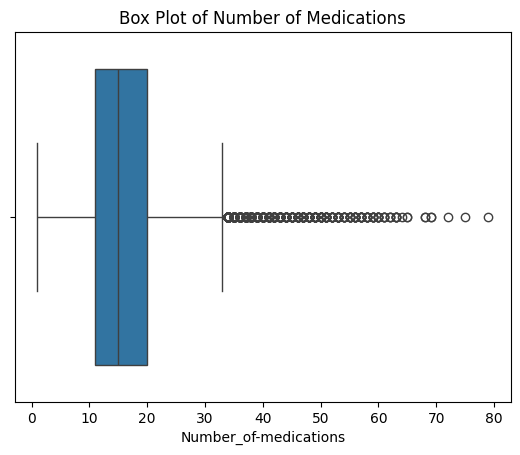

In [339]:
# checking outliers in number of medications clumn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=df_selected['Number_of_medications'])
plt.title('Box Plot of Number of Medications')
plt.xlabel('Number_of-medications')
plt.show()


In [340]:
# capping the number of medications
# Step 1: Calculate IQR and limits
Q1 = df_selected['Number_of_medications'].quantile(0.25)
Q3 = df_selected['Number_of_medications'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
# Step 2: Keep only non-outlier rows
df_selected = df_selected[(df_selected['Number_of_medications'] >= lower_limit) &
                          (df_selected['Number_of_medications'] <= upper_limit)]


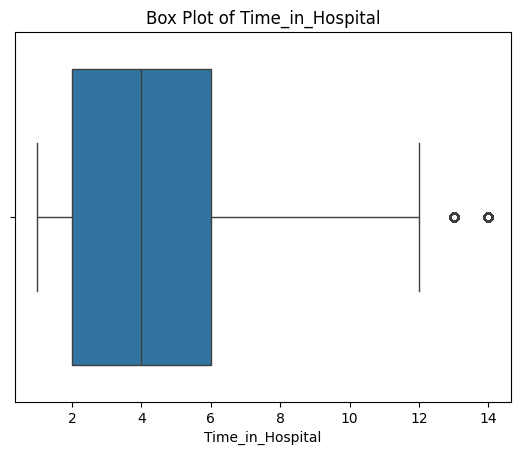

In [341]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=df_selected['Time_in_Hospital'])
plt.title('Box Plot of Time_in_Hospital')
plt.xlabel('Time_in_Hospital')
plt.show()

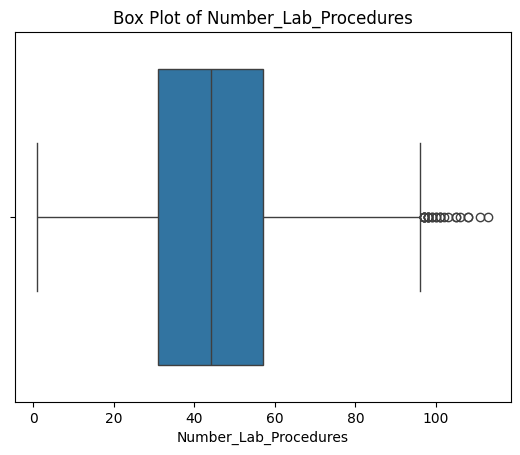

In [342]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=df_selected['Number_Lab_Procedures'])
plt.title('Box Plot of Number_Lab_Procedures')
plt.xlabel('Number_Lab_Procedures')
plt.show()

In [343]:
# capping the number of Lab_procedures

Q1 = df_selected['Number_Lab_Procedures'].quantile(0.25)
Q3 = df_selected['Number_Lab_Procedures'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Step 2: Keep only non-outlier rows
df_selected = df_selected[(df_selected['Number_Lab_Procedures'] >= lower_limit) &
                          (df_selected['Number_Lab_Procedures'] <= upper_limit)]

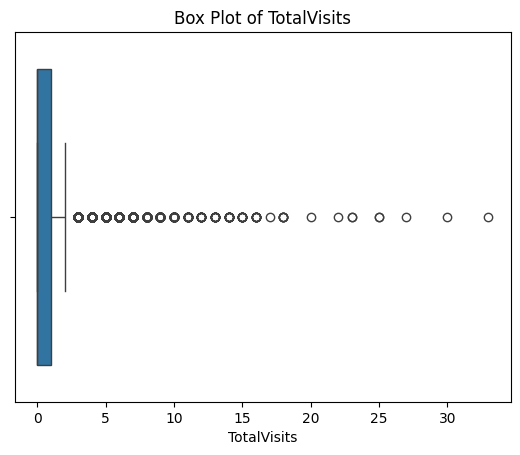

In [344]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=df_selected['TotalVisits'])
plt.title('Box Plot of TotalVisits')
plt.xlabel('TotalVisits')
plt.show()
# dont touch ths as it can be importnat to us

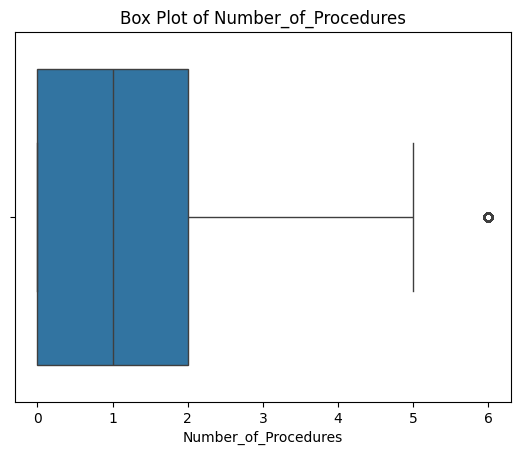

In [345]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=df_selected['Number_of_Procedures'])
plt.title('Box Plot of Number_of_Procedures')
plt.xlabel('Number_of_Procedures')
plt.show()
# it is not needed to be removed

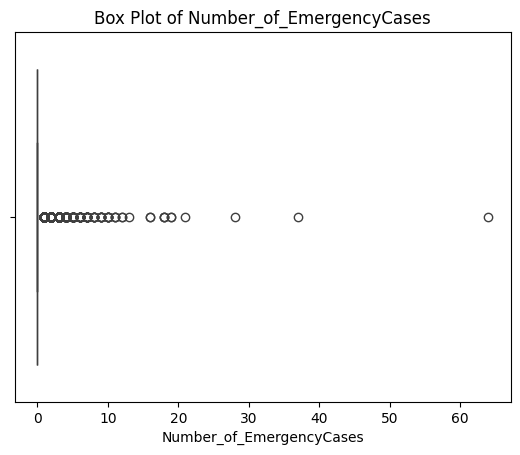

In [346]:
sns.boxplot(x=df_selected['Number_of_EmergencyCases'])
plt.title('Box Plot of Number_of_EmergencyCases')
plt.xlabel('Number_of_EmergencyCases')
plt.show()

In [347]:
df = df.drop_duplicates()


In [348]:
df_selected.info

<bound method DataFrame.info of            Age  Time_in_Hospital  Number_Lab_Procedures  Number_of_Procedures  \
0      [70-80)                 8                     72                     1   
1      [70-80)                 3                     34                     2   
2      [50-60)                 5                     45                     0   
3      [70-80)                 2                     36                     0   
4      [60-70)                 1                     42                     0   
...        ...               ...                    ...                   ...   
24995  [80-90)                14                     77                     1   
24996  [80-90)                 2                     66                     0   
24997  [70-80)                 5                     12                     0   
24998  [70-80)                 2                     61                     3   
24999  [50-60)                10                     37                     1

In [349]:
df_selected.isna().sum() *100

Age                              0
Time_in_Hospital                 0
Number_Lab_Procedures            0
Number_of_Procedures             0
Number_of_medications            0
Number_of_EmergencyCases         0
Medical_Departments              0
Diagnosis_1st                    0
Diagnosis_2nd                    0
Diagnosis_3rd                    0
Glucose_Test                     0
A1C_Test                         0
Diabetes_Medicines_prescribed    0
ReAdmitted                       0
Number of OutPatient             0
Number of InPatient              0
TotalVisits                      0
dtype: int64

In [350]:
df_selected.dtypes

Age                              object
Time_in_Hospital                  int64
Number_Lab_Procedures             int64
Number_of_Procedures              int64
Number_of_medications             int64
Number_of_EmergencyCases          int64
Medical_Departments              object
Diagnosis_1st                    object
Diagnosis_2nd                    object
Diagnosis_3rd                    object
Glucose_Test                     object
A1C_Test                         object
Diabetes_Medicines_prescribed    object
ReAdmitted                       object
Number of OutPatient              int64
Number of InPatient               int64
TotalVisits                       int64
dtype: object

In [351]:
df_selected['Time_in_Hospital'].describe()


count    24129.000000
mean         4.317958
std          2.906682
min          1.000000
25%          2.000000
50%          4.000000
75%          6.000000
max         14.000000
Name: Time_in_Hospital, dtype: float64

In [352]:
# lets do Visualization now>>>

In [353]:
df_selected.head()

,Age,Time_in_Hospital,Number_Lab_Procedures,Number_of_Procedures,Number_of_medications,Number_of_EmergencyCases,Medical_Departments,Diagnosis_1st,Diagnosis_2nd,Diagnosis_3rd,Glucose_Test,A1C_Test,Diabetes_Medicines_prescribed,ReAdmitted,Number of OutPatient,Number of InPatient,TotalVisits
0,[70-80),8,72,1,18,0,Missing,Circulatory,Respiratory,Other,no,no,yes,no,2,0,2
1,[70-80),3,34,2,13,0,Other,Other,Other,Other,no,no,yes,no,0,0,0
2,[50-60),5,45,0,18,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,0,0,0
3,[70-80),2,36,0,12,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,1,0,1
4,[60-70),1,42,0,7,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,yes,no,0,0,0


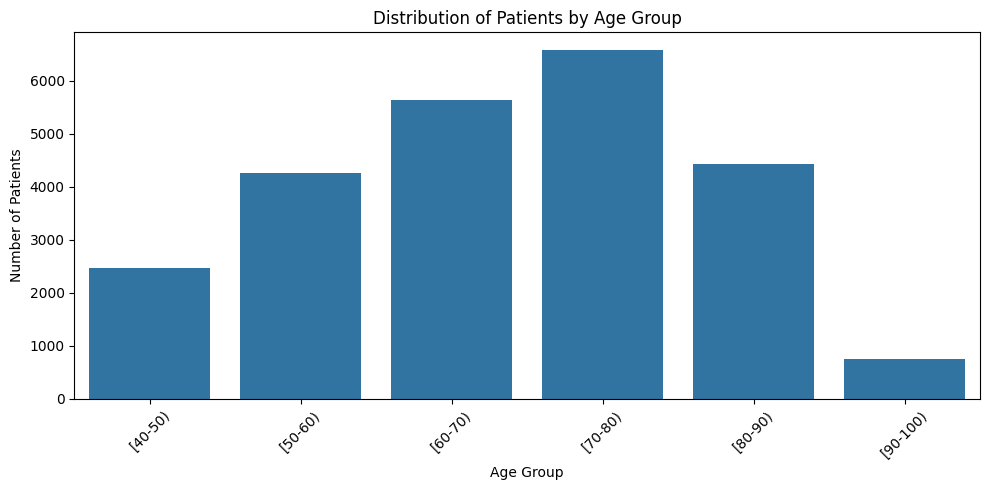

In [354]:
plt.figure(figsize=(10,5))
sns.countplot(data=df_selected, x='Age', order=sorted(df_selected['Age'].unique()))
plt.title('Distribution of Patients by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [355]:
# here you can se that 70-80 age group have high number of patients 

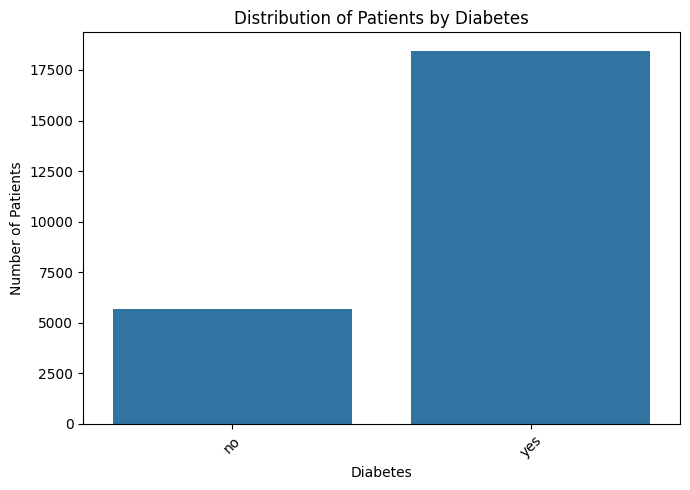

In [356]:
plt.figure(figsize=(7,5))
sns.countplot(data=df_selected, x='Diabetes_Medicines_prescribed', order=sorted(df_selected['Diabetes_Medicines_prescribed'].unique()))
plt.title('Distribution of Patients by Diabetes')
plt.xlabel('Diabetes')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# ye bata rha hai kidiabetes medicine kitne number of students le rhe hai

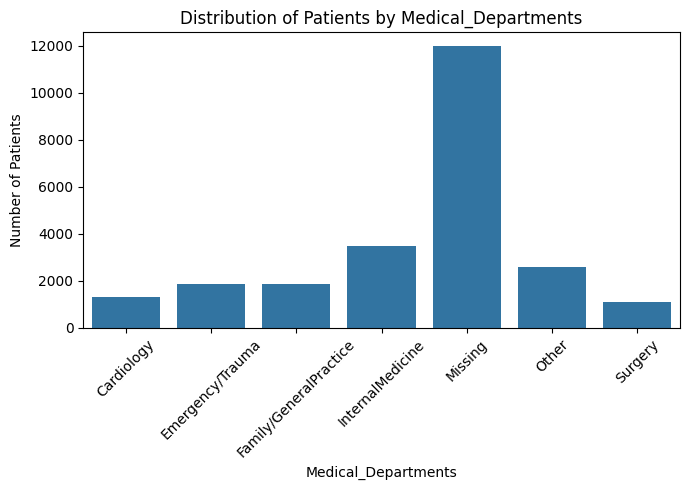

In [357]:
plt.figure(figsize=(7,5))
sns.countplot(data=df_selected, x='Medical_Departments', order=sorted(df_selected['Medical_Departments'].unique()))
plt.title('Distribution of Patients by Medical_Departments')
plt.xlabel('Medical_Departments')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# diferen medical department ke hisaab se number of patients 

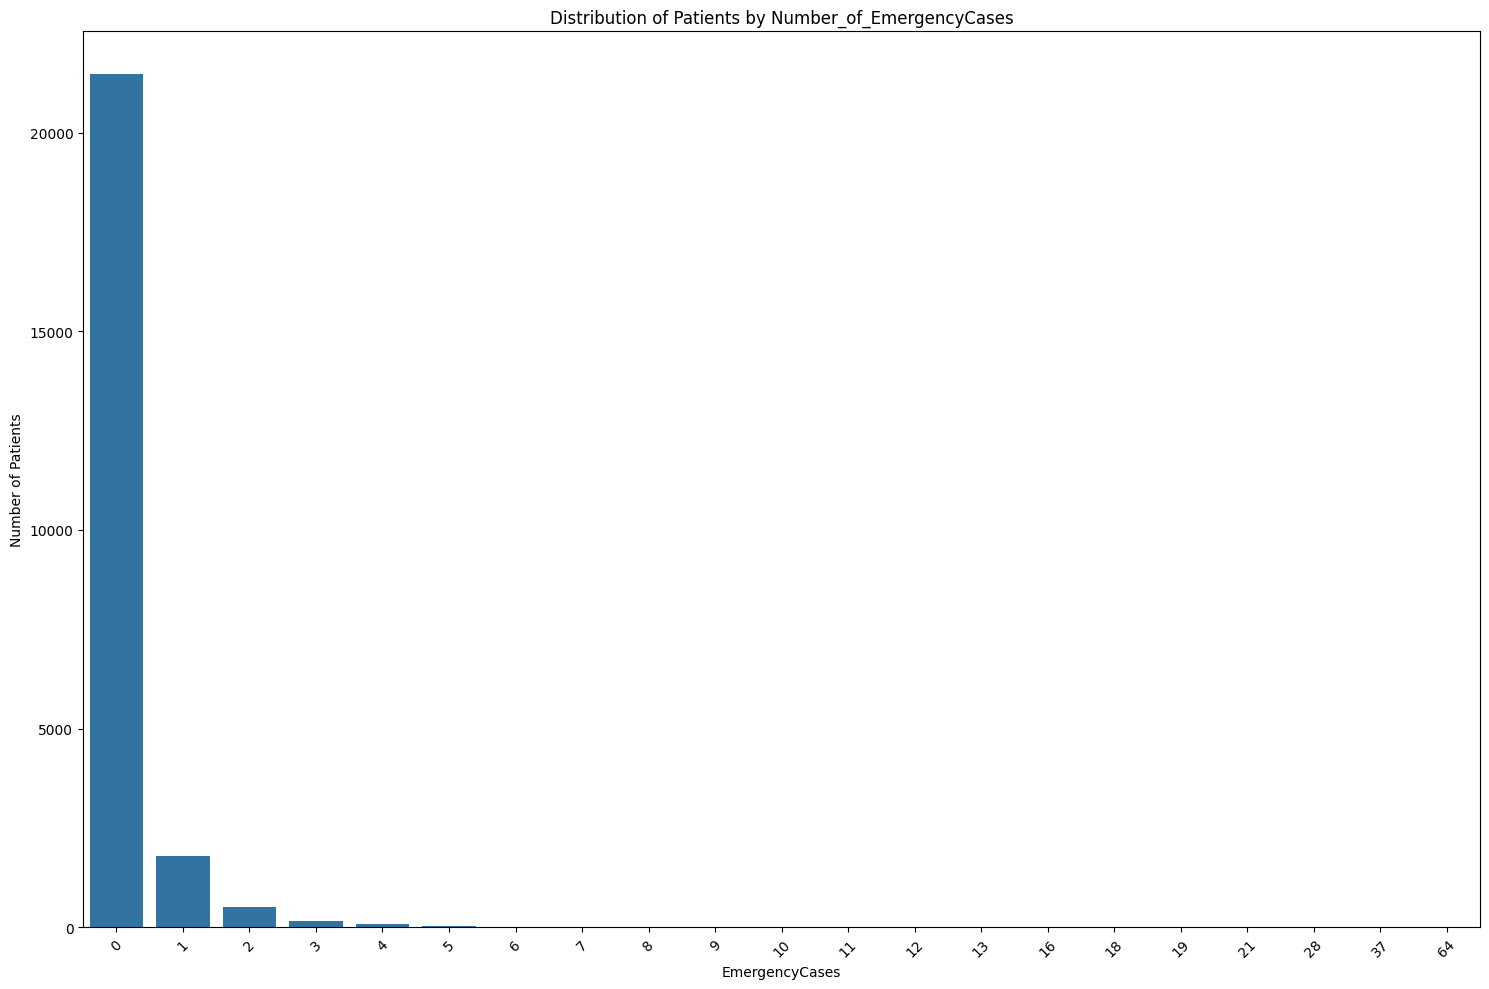

In [358]:
plt.figure(figsize=(15,10))
sns.countplot(data=df_selected, x='Number_of_EmergencyCases', order=sorted(df_selected['Number_of_EmergencyCases'].unique()))
plt.title('Distribution of Patients by Number_of_EmergencyCases')
plt.xlabel('EmergencyCases')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# emergency cases and number of patents

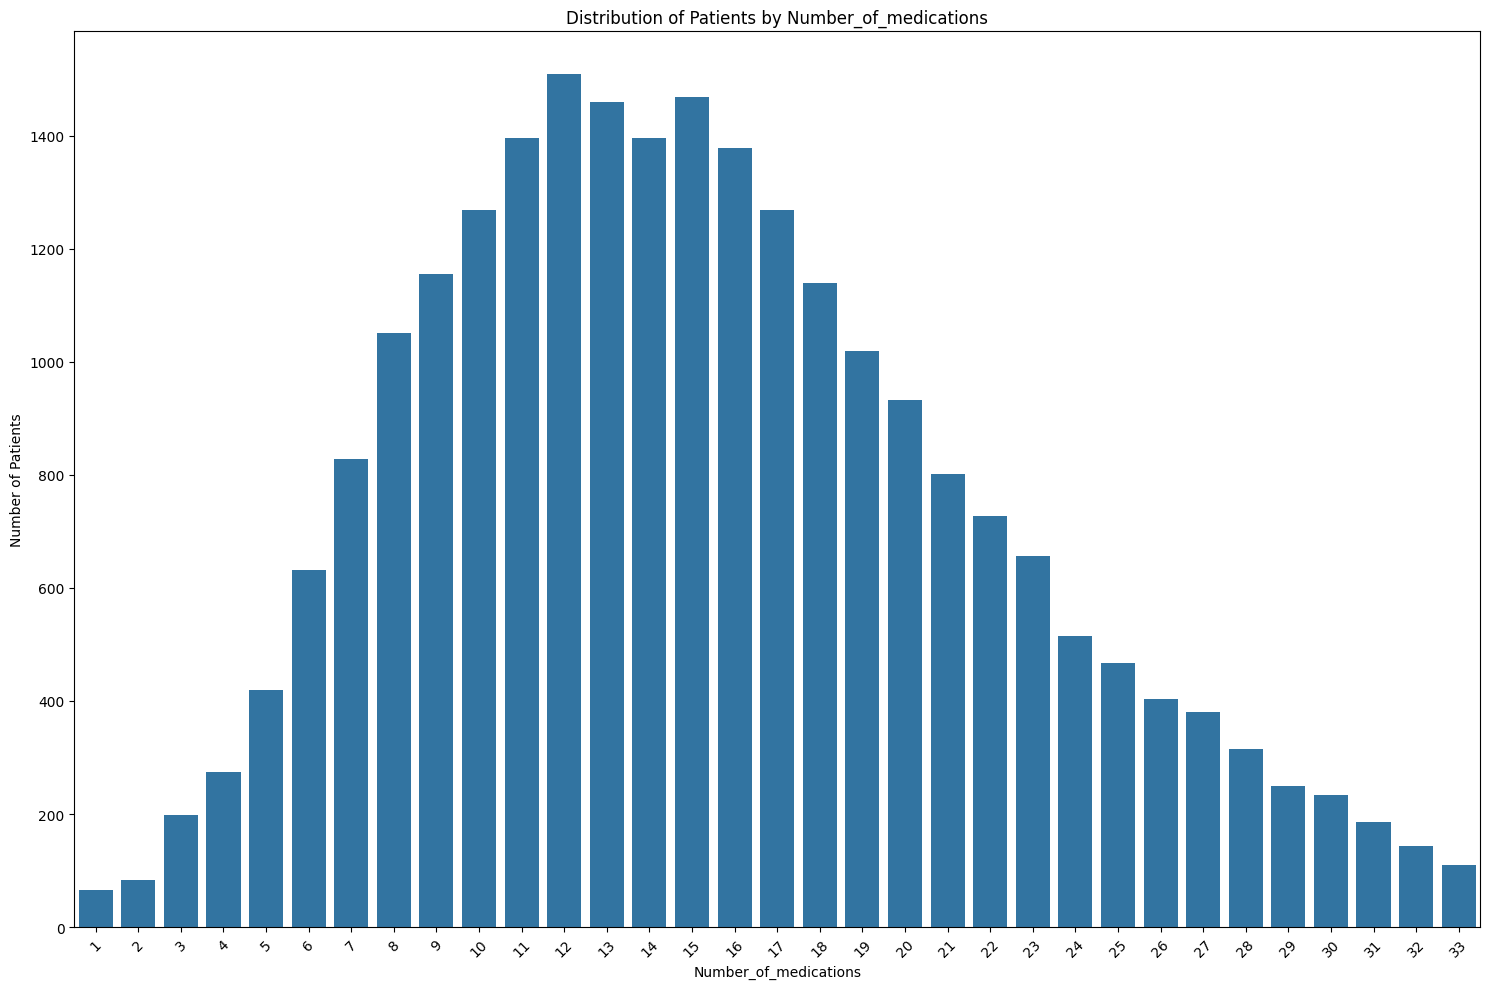

In [359]:
plt.figure(figsize=(15,10))
sns.countplot(data=df_selected, x='Number_of_medications', order=sorted(df_selected['Number_of_medications'].unique()))
plt.title('Distribution of Patients by Number_of_medications')
plt.xlabel('Number_of_medications')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# isse to kya hi insights mil rhi hai but check krlena theek hai

C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_3696\2003467439.py:7: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HARSHIT SHARMA\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


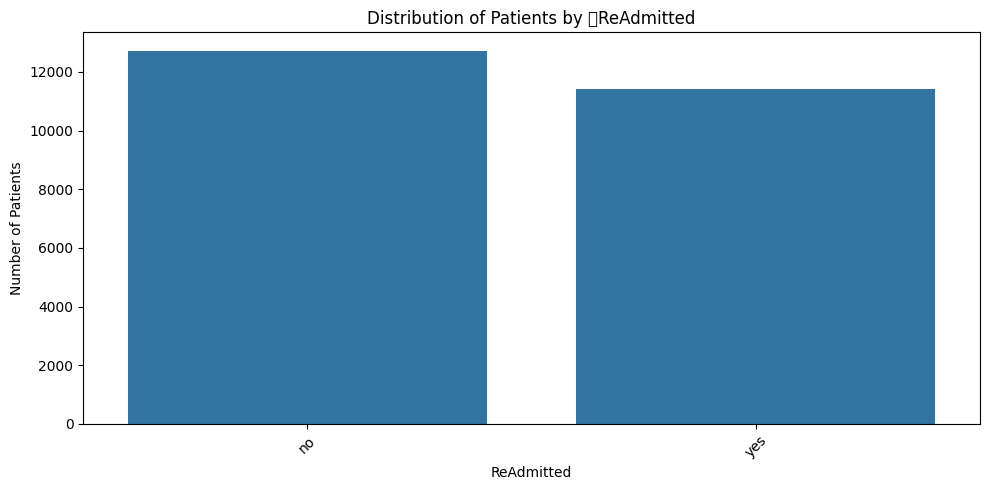

In [360]:
plt.figure(figsize=(10,5))
sns.countplot(data=df_selected, x='ReAdmitted', order=sorted(df_selected['ReAdmitted'].unique()))
plt.title('Distribution of Patients by 	ReAdmitted')
plt.xlabel('ReAdmitted')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# readmitted hue kitne patients batarhe hai?

In [361]:
# BiVariate analysis

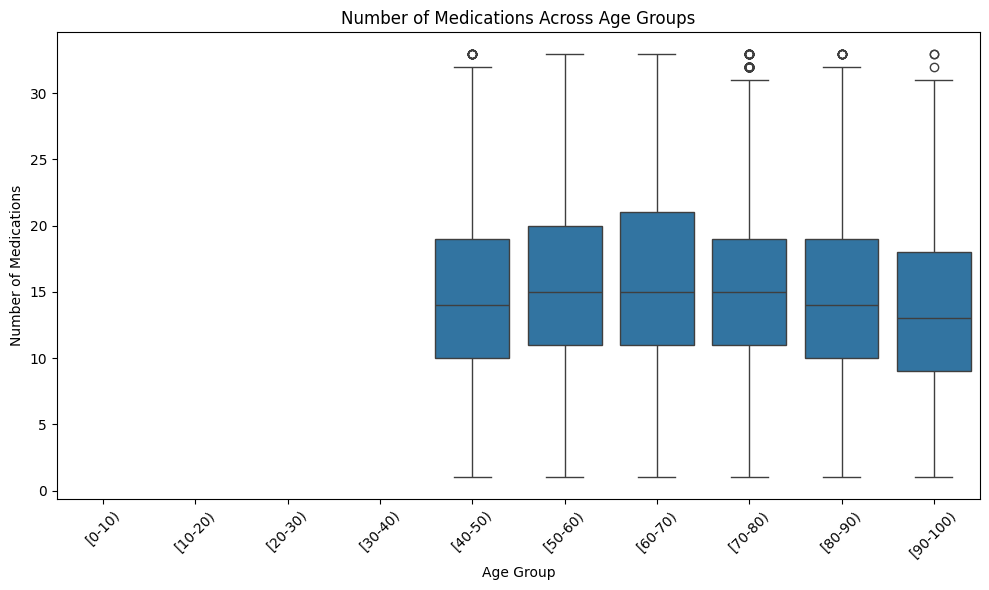

In [362]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_selected, x='Age', y='Number_of_medications', order=[
    '[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', 
    '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'
])
plt.title('Number of Medications Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Medications')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# number of medication aming different age groups

In [363]:
# i dont know if this is important or not but i am doing this for me

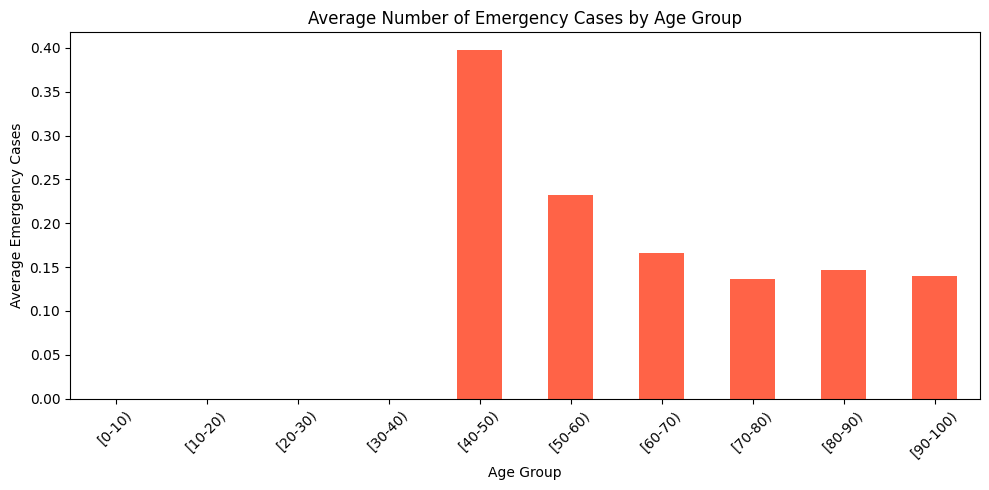

In [364]:
avg_emergency = df_selected.groupby('Age')['Number_of_EmergencyCases'].mean().reindex([
    '[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
    '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'
])

avg_emergency.plot(kind='bar', figsize=(10,5), color='tomato')
plt.title('Average Number of Emergency Cases by Age Group')
plt.ylabel('Average Emergency Cases')
plt.xlabel('Age Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# number of emergency among different age groupos

In [365]:
# Patients aged 40–50 have a higher average number of emergency hospital visits compared to other age groups

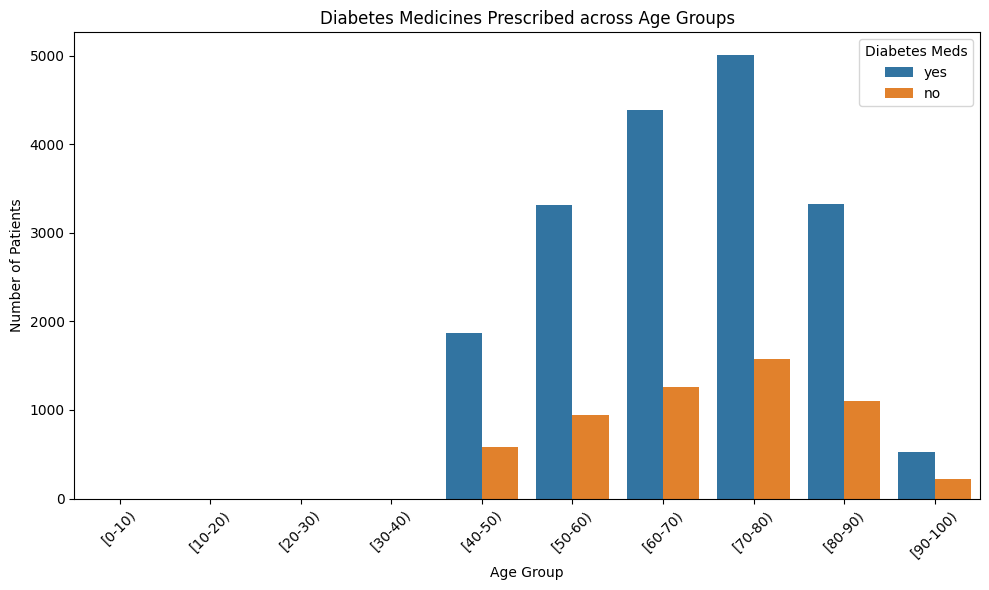

In [366]:

plt.figure(figsize=(10,6))
sns.countplot(data=df_selected, x='Age', hue='Diabetes_Medicines_prescribed', 
              order=['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', 
                     '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'])
plt.title('Diabetes Medicines Prescribed across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.legend(title='Diabetes Meds')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [367]:
# Konsi age group me zyada diabetes meds diye ja rahe hain

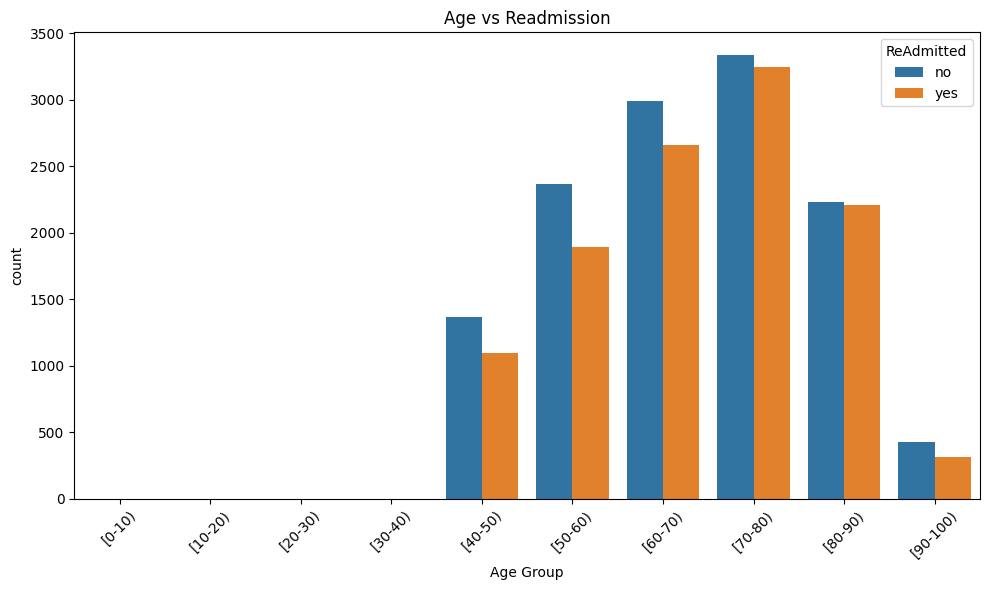

In [368]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_selected, x='Age', hue='ReAdmitted', 
              order=['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)', 
                     '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'])
plt.title('Age vs Readmission')
plt.xlabel('Age Group')
# plt.ylabel('Patient Count')
plt.legend(title='ReAdmitted')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [369]:
# Konsi age group me readmission rate high hai

In [370]:
df_selected.head()

,Age,Time_in_Hospital,Number_Lab_Procedures,Number_of_Procedures,Number_of_medications,Number_of_EmergencyCases,Medical_Departments,Diagnosis_1st,Diagnosis_2nd,Diagnosis_3rd,Glucose_Test,A1C_Test,Diabetes_Medicines_prescribed,ReAdmitted,Number of OutPatient,Number of InPatient,TotalVisits
0,[70-80),8,72,1,18,0,Missing,Circulatory,Respiratory,Other,no,no,yes,no,2,0,2
1,[70-80),3,34,2,13,0,Other,Other,Other,Other,no,no,yes,no,0,0,0
2,[50-60),5,45,0,18,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,0,0,0
3,[70-80),2,36,0,12,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,1,0,1
4,[60-70),1,42,0,7,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,yes,no,0,0,0


C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_3696\3265554830.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_meds.index, y=avg_meds.values, palette='viridis')


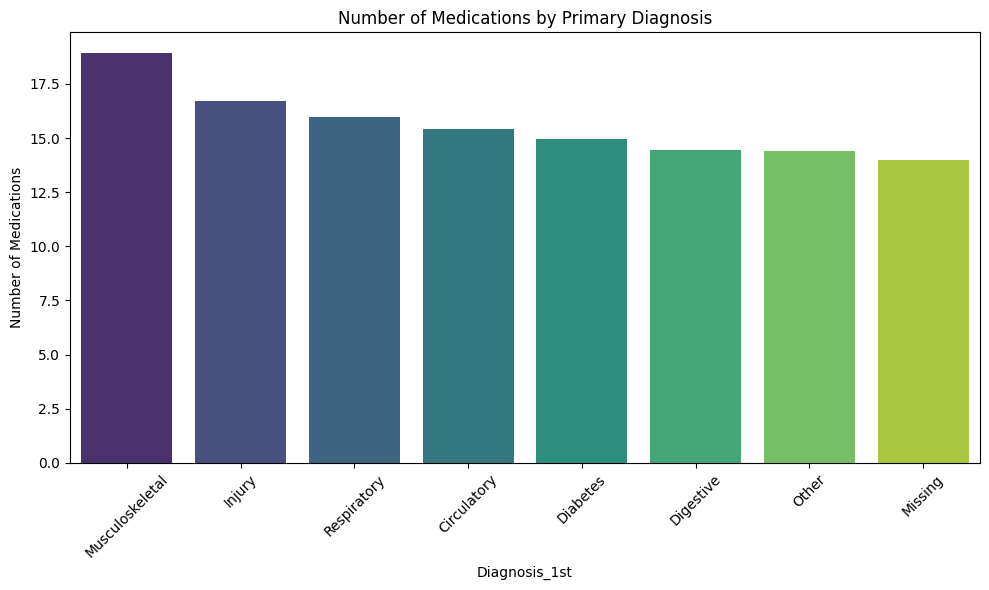

In [371]:
plt.figure(figsize=(10,6))

# Grouping data: Diagnosis_1st vs avg number of medications
avg_meds = df_selected.groupby('Diagnosis_1st')['Number_of_medications'].mean().sort_values(ascending=False)

# Plot bar chart
sns.barplot(x=avg_meds.index, y=avg_meds.values, palette='viridis')

plt.title('Number of Medications by Primary Diagnosis')
plt.xlabel('Diagnosis_1st')
plt.ylabel('Number of Medications')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [372]:
# this shows us that the number mediaction used per diagonisis1st and it is highest in musculoskeletal

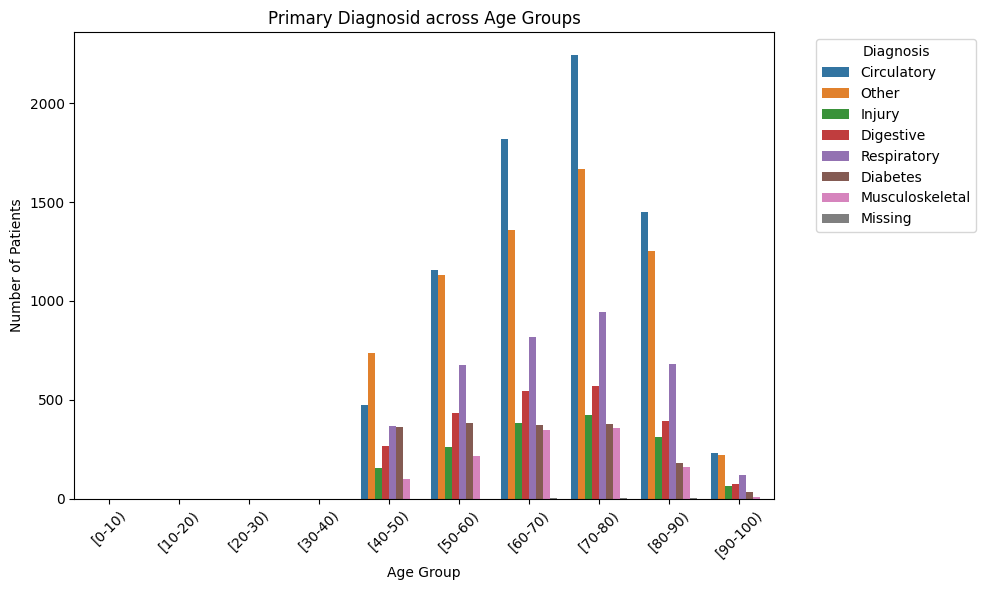

In [373]:
plt.figure(figsize=(10,6))
sns.countplot(data=df_selected, x='Age', hue='Diagnosis_1st',
              order=['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
                     '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'])

plt.title('Primary Diagnosid across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.legend(title='Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [374]:
# Diagnosis-wise distribution across age groups shows that diabetes and circulatory disorders dominate among 70-80 age group

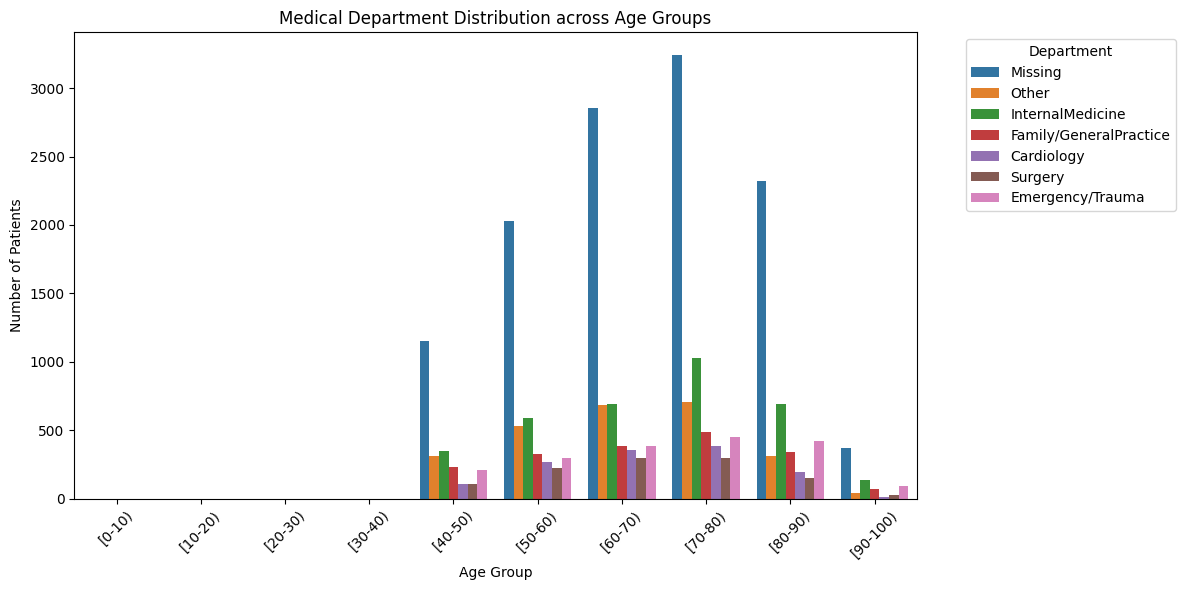

In [375]:
plt.figure(figsize=(12,6))

# Clean legend — filter top 10 departments for clarity
top_depts = df_selected['Medical_Departments'].value_counts().nlargest(10).index
filtered_df = df_selected[df_selected['Medical_Departments'].isin(top_depts)]

sns.countplot(data=filtered_df, x='Age', hue='Medical_Departments',
              order=['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
                     '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'])

plt.title('Medical Department Distribution across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.legend(title='Department', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [376]:
# this will tell us the number of patient kis department me ilaaj krwarhe hai in different age groups

C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_3696\1502296898.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


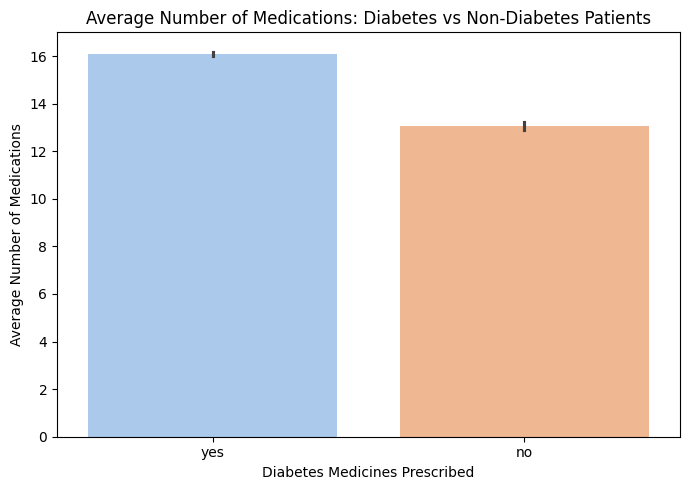

In [377]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df_selected,
    x='Diabetes_Medicines_prescribed',
    y='Number_of_medications',
    palette='pastel'
)

plt.title('Average Number of Medications: Diabetes vs Non-Diabetes Patients')
plt.xlabel('Diabetes Medicines Prescribed')
plt.ylabel('Average Number of Medications')
plt.tight_layout()
plt.show()


In [378]:
# ye analyse krrha hai ki diabetes ko juada dawai mil rhi h ya nahi i know this is not that useful but i am just tryng

C:\Users\HARSHIT SHARMA\AppData\Local\Temp\ipykernel_3696\2493244945.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


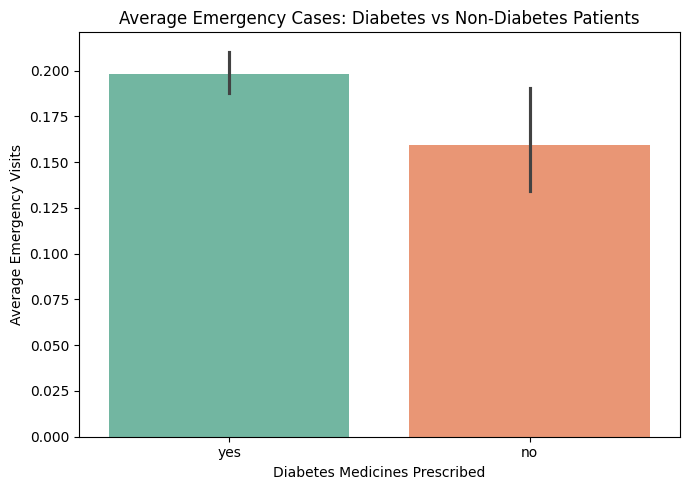

In [379]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=df_selected,
    x='Diabetes_Medicines_prescribed',
    y='Number_of_EmergencyCases',
    palette='Set2'
)

plt.title('Average Emergency Cases: Diabetes vs Non-Diabetes Patients')
plt.xlabel('Diabetes Medicines Prescribed')
plt.ylabel('Average Emergency Visits')
plt.tight_layout()
plt.show()


In [380]:
# plt.figure(figsize=(6,5))

# sns.countplot(
#     data=df_selected,
#     x='Glucose_Test',
#     hue='Diabetes_Medicines_prescribed',
#     palette='Set2'
# )

# plt.title('Glucose Test vs Diabetes Medicines Prescribed')
# plt.xlabel('Glucose Test Performed')
# plt.ylabel('Number of Patients')
# plt.legend(title='Diabetes Meds Prescribed')
# plt.tight_layout()
# plt.show()



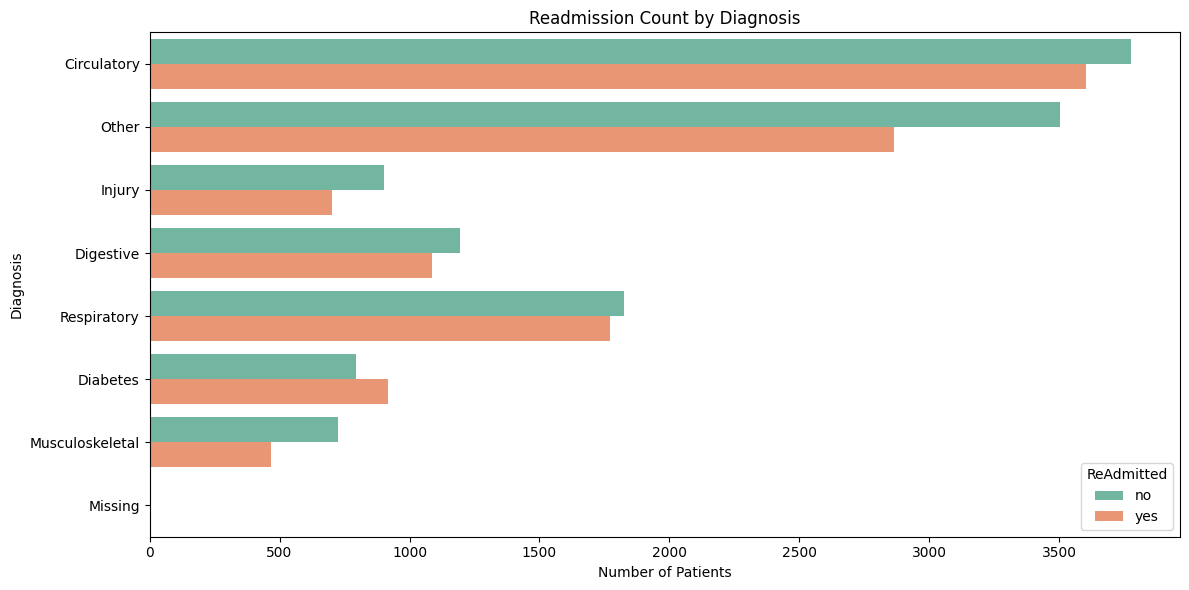

In [381]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_selected,
    y='Diagnosis_1st',
    hue='ReAdmitted',
    palette='Set2'
)
plt.title('Readmission Count by Diagnosis')
plt.xlabel('Number of Patients')
plt.ylabel('Diagnosis')
plt.legend(title='ReAdmitted')
plt.tight_layout()
plt.show()


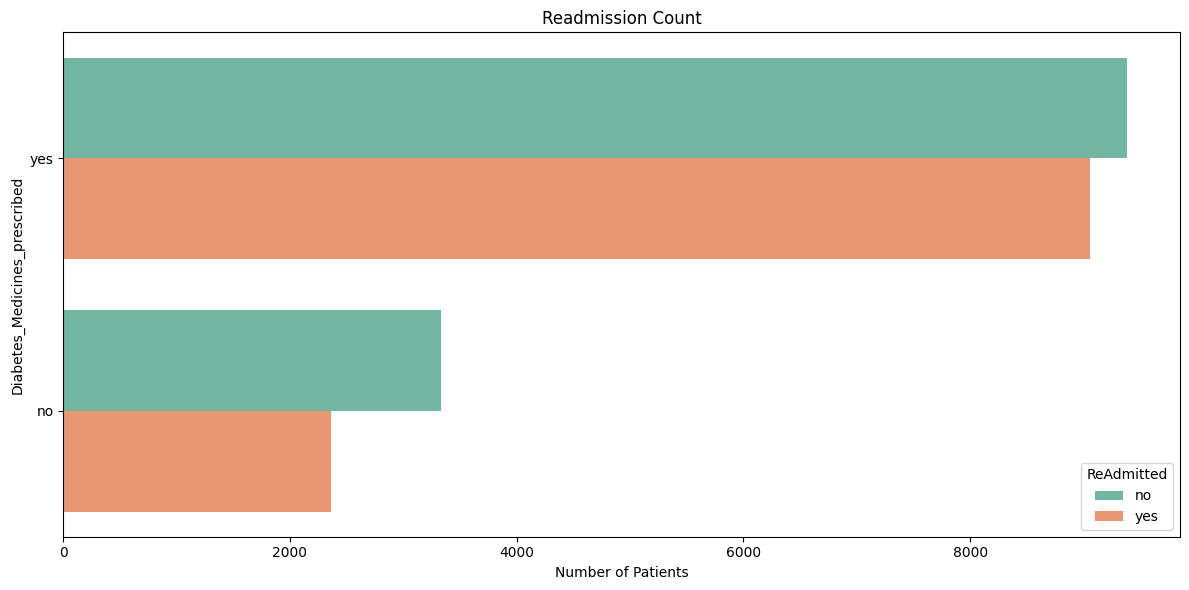

In [382]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_selected,
    y='Diabetes_Medicines_prescribed',
    hue='ReAdmitted',
    palette='Set2'
)
plt.title('Readmission Count')
plt.xlabel('Number of Patients')
plt.ylabel('Diabetes_Medicines_prescribed')
plt.legend(title='ReAdmitted')
plt.tight_layout()
plt.show()


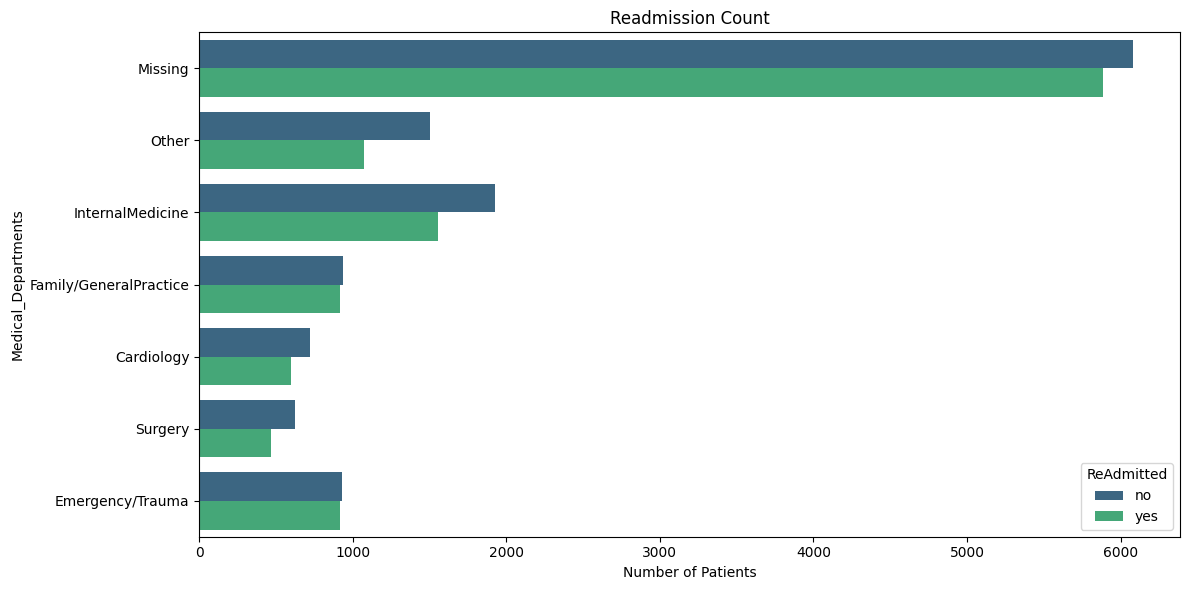

In [383]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_selected,
    y='Medical_Departments',
    hue='ReAdmitted',
    palette='viridis'
)
plt.title('Readmission Count')
plt.xlabel('Number of Patients')
plt.ylabel('Medical_Departments')
plt.legend(title='ReAdmitted')
plt.tight_layout()
plt.show()

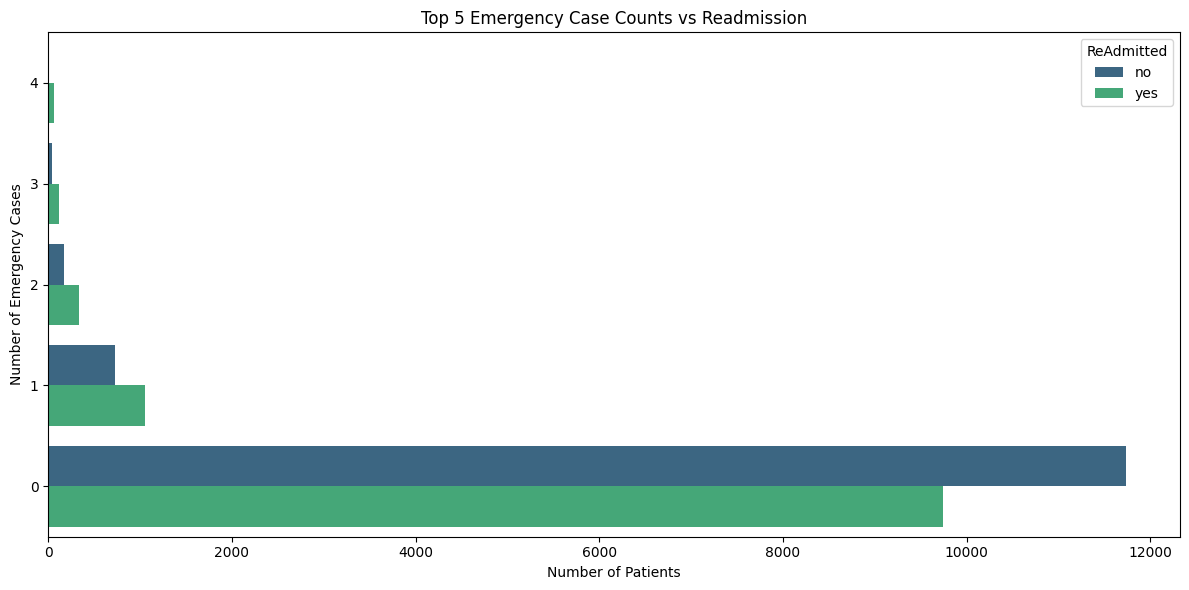

In [384]:
# plt.figure(figsize=(12, 6))
# sns.countplot(
#     data=df_selected,
#     y='Number_of_EmergencyCases',
#     hue='ReAdmitted',
#     palette='viridis'
# )
# plt.title('Readmission Count')
# plt.xlabel('Number of Patients')
# plt.ylabel('Number_of_EmergencyCases')
# plt.legend(title='ReAdmitted')
# plt.tight_layout()
# plt.show()


import seaborn as sns
import matplotlib.pyplot as plt


top_emergency = (
    df_selected['Number_of_EmergencyCases']
    .value_counts()
    .nlargest(5)
    .index
)


filtered_emergency_df = df_selected[df_selected['Number_of_EmergencyCases'].isin(top_emergency)]


plt.figure(figsize=(12, 6))
sns.countplot(
    data=filtered_emergency_df,
    y='Number_of_EmergencyCases',
    hue='ReAdmitted',
    palette='viridis',
    order=sorted(top_emergency, reverse=True)
)
plt.title('Top 5 Emergency Case Counts vs Readmission')
plt.xlabel('Number of Patients')
plt.ylabel('Number of Emergency Cases')
plt.legend(title='ReAdmitted')
plt.tight_layout()
plt.show()


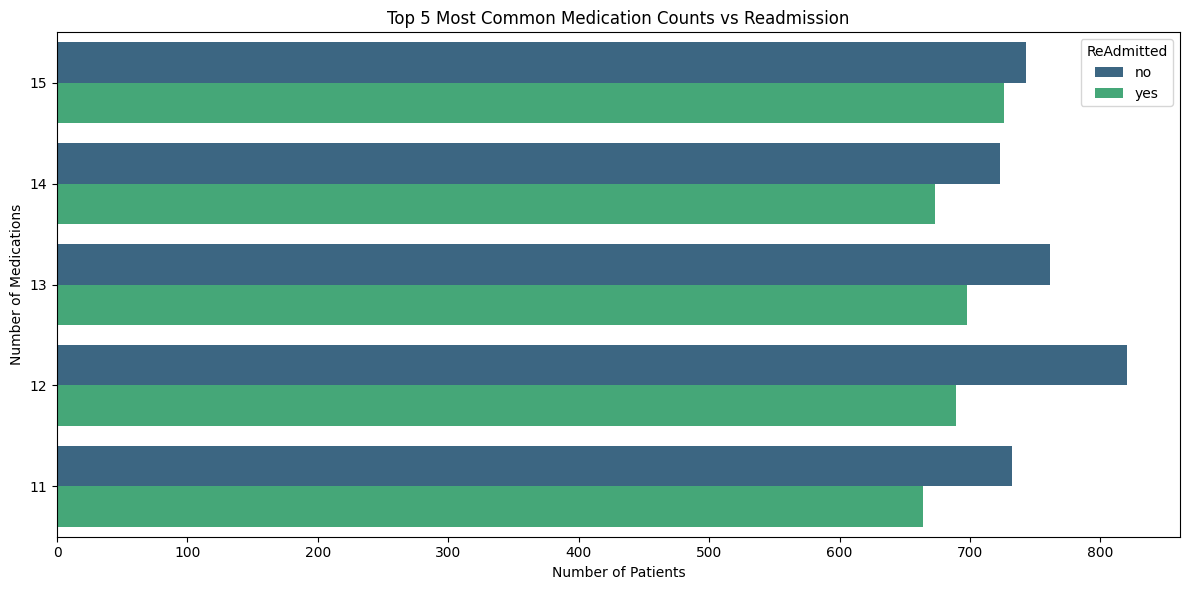

In [385]:
top_med_counts = (
    df_selected['Number_of_medications']
    .value_counts()
    .nlargest(5)
    .index
)

# Filter only those top 5 values
filtered_df = df_selected[df_selected['Number_of_medications'].isin(top_med_counts)]

# Plot
plt.figure(figsize=(12, 6))
sns.countplot(
    data=filtered_df,
    y='Number_of_medications',
    hue='ReAdmitted',
    palette='viridis',
    order=sorted(top_med_counts, reverse=True)  # Optional: largest at top
)
plt.title('Top 5 Most Common Medication Counts vs Readmission')
plt.xlabel('Number of Patients')
plt.ylabel('Number of Medications')
plt.legend(title='ReAdmitted')
plt.tight_layout()
plt.show()
# ye to cluttered hai bahot

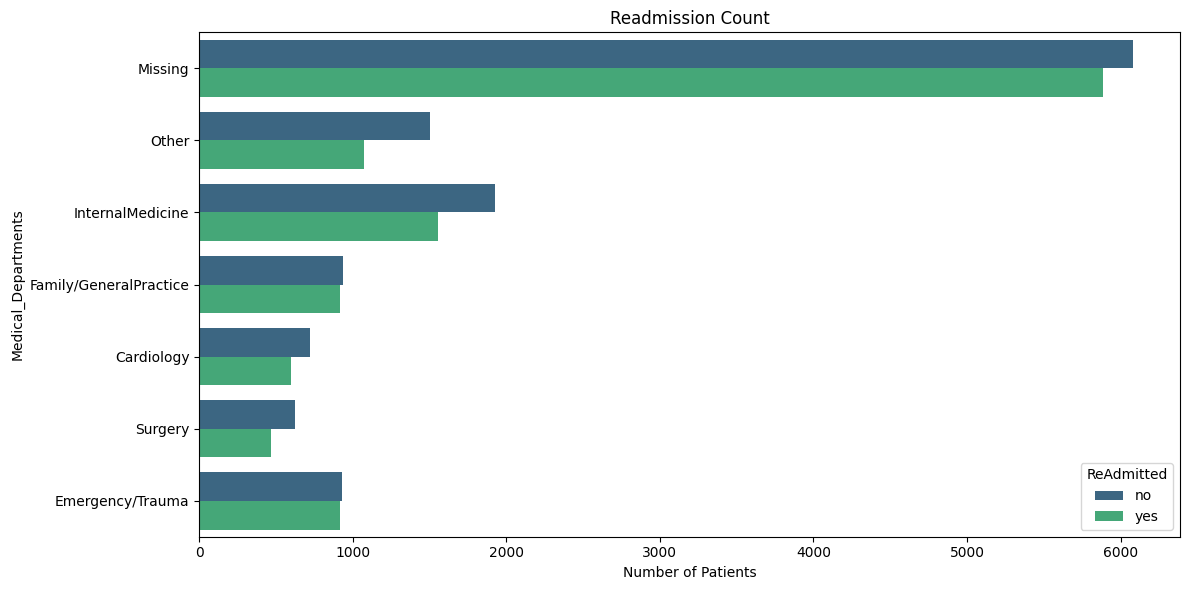

In [386]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_selected,
    y='Medical_Departments',
    hue='ReAdmitted',
    palette='viridis'
)
plt.title('Readmission Count')
plt.xlabel('Number of Patients')
plt.ylabel('Medical_Departments')
plt.legend(title='ReAdmitted')
plt.tight_layout()
plt.show()

In [387]:
numeric_df = df_selected.select_dtypes(include='number')


In [388]:
corr_matrix = numeric_df.corr()


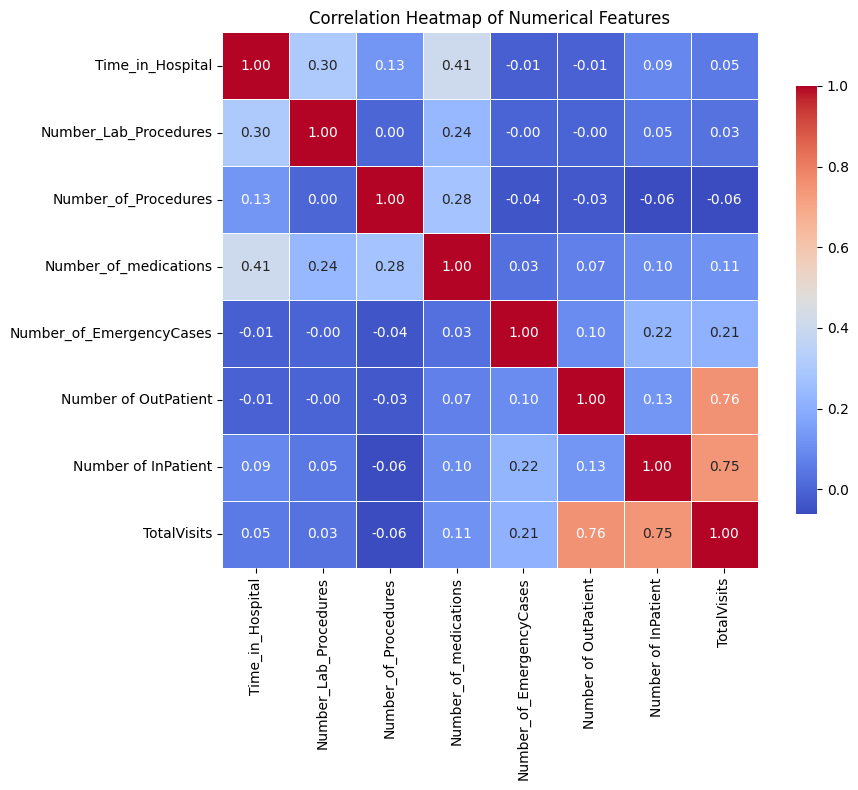

In [389]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,         # show correlation values
    fmt=".2f",          # two decimal places
    cmap='coolwarm',    # color scale
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()


In [390]:
df_selected.to_csv('final_cleaned_dataset.csv', index=False)